In [ ]:
import numpy as np
import pandas as pd
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")
sample_submission = pd.read_csv("/content/sample_submission.csv")
train.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,1,1,1,0,1,1,...,f,White-European,no,no,United States,no,7.819715,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,f,South Asian,no,no,Australia,no,10.544296,18 and more,?,0
2,3,1,1,1,1,1,1,0,0,1,...,f,White-European,no,no,United Kingdom,no,13.167506,18 and more,Self,1
3,4,0,0,0,1,0,0,0,0,0,...,f,South Asian,no,no,New Zealand,no,1.530098,18 and more,?,0
4,5,0,0,0,0,1,0,0,0,1,...,m,Black,no,yes,Italy,no,7.949723,18 and more,Self,0


In [ ]:
train.isnull().sum()

ID                 0
A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                0
gender             0
ethnicity          0
jaundice           0
austim             0
contry_of_res      0
used_app_before    0
result             0
age_desc           0
relation           0
Class/ASD          0
dtype: int64

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    float64
 12  gender           800 non-null    object 
 13  ethnicity        800 non-null    object 
 14  jaundice         800 non-null    object 
 15  austim           800 non-null    object 
 16  contry_of_res    800 non-null    object 
 17  used_app_before 

In [ ]:
train['age'] = train['age'].astype(int,errors='ignore')

In [ ]:
train.drop_duplicates(inplace=True)
train

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,1,1,1,0,1,1,...,f,White-European,no,no,United States,no,7.819715,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,f,South Asian,no,no,Australia,no,10.544296,18 and more,?,0
2,3,1,1,1,1,1,1,0,0,1,...,f,White-European,no,no,United Kingdom,no,13.167506,18 and more,Self,1
3,4,0,0,0,1,0,0,0,0,0,...,f,South Asian,no,no,New Zealand,no,1.530098,18 and more,?,0
4,5,0,0,0,0,1,0,0,0,1,...,m,Black,no,yes,Italy,no,7.949723,18 and more,Self,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,1,1,1,1,1,1,1,1,1,...,f,White-European,no,yes,United States,no,13.390868,18 and more,Self,1
796,797,1,1,0,0,1,0,0,0,1,...,f,Asian,no,no,New Zealand,no,9.454201,18 and more,Self,0
797,798,0,0,0,0,0,0,1,0,1,...,m,White-European,yes,no,Jordan,no,6.805509,18 and more,Self,1
798,799,1,1,1,1,1,1,0,1,1,...,f,Middle Eastern,no,yes,United States,no,3.682732,18 and more,Relative,0


In [ ]:
train.columns

Index(['ID', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
       'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age',
       'gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='object')

In [ ]:
train = train.drop(["contry_of_res","age_desc"], axis=1)
train

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,used_app_before,result,relation,Class/ASD
0,1,1,0,1,1,1,1,0,1,1,1,18,f,White-European,no,no,no,7.819715,Self,0
1,2,0,0,0,0,0,0,0,0,0,1,13,f,South Asian,no,no,no,10.544296,?,0
2,3,1,1,1,1,1,1,0,0,1,1,14,f,White-European,no,no,no,13.167506,Self,1
3,4,0,0,0,1,0,0,0,0,0,0,61,f,South Asian,no,no,no,1.530098,?,0
4,5,0,0,0,0,1,0,0,0,1,1,14,m,Black,no,yes,no,7.949723,Self,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,1,1,1,1,1,1,1,1,1,1,42,f,White-European,no,yes,no,13.390868,Self,1
796,797,1,1,0,0,1,0,0,0,1,1,17,f,Asian,no,no,no,9.454201,Self,0
797,798,0,0,0,0,0,0,1,0,1,1,18,m,White-European,yes,no,no,6.805509,Self,1
798,799,1,1,1,1,1,1,0,1,1,1,19,f,Middle Eastern,no,yes,no,3.682732,Relative,0


In [ ]:
train = train.rename(columns={'austim':'autism'})
train

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,autism,used_app_before,result,relation,Class/ASD
0,1,1,0,1,1,1,1,0,1,1,1,18,f,White-European,no,no,no,7.819715,Self,0
1,2,0,0,0,0,0,0,0,0,0,1,13,f,South Asian,no,no,no,10.544296,?,0
2,3,1,1,1,1,1,1,0,0,1,1,14,f,White-European,no,no,no,13.167506,Self,1
3,4,0,0,0,1,0,0,0,0,0,0,61,f,South Asian,no,no,no,1.530098,?,0
4,5,0,0,0,0,1,0,0,0,1,1,14,m,Black,no,yes,no,7.949723,Self,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,1,1,1,1,1,1,1,1,1,1,42,f,White-European,no,yes,no,13.390868,Self,1
796,797,1,1,0,0,1,0,0,0,1,1,17,f,Asian,no,no,no,9.454201,Self,0
797,798,0,0,0,0,0,0,1,0,1,1,18,m,White-European,yes,no,no,6.805509,Self,1
798,799,1,1,1,1,1,1,0,1,1,1,19,f,Middle Eastern,no,yes,no,3.682732,Relative,0


In [ ]:
train.gender.unique()

array(['f', 'm'], dtype=object)

In [ ]:
train.jaundice.unique()

array(['no', 'yes'], dtype=object)

In [ ]:
train.autism.unique()

array(['no', 'yes'], dtype=object)

In [ ]:
train.used_app_before.unique()

array(['no', 'yes'], dtype=object)

In [ ]:
train.relation.unique()

array(['Self', '?', 'Health care professional', 'Parent', 'Relative',
       'Others'], dtype=object)

In [ ]:
train.ethnicity.unique()

array(['White-European', 'South Asian', 'Black', 'Asian',
       'Middle Eastern ', '?', 'others', 'Latino', 'Turkish', 'Others',
       'Hispanic', 'Pasifika'], dtype=object)

### Handling the Inappropriate Values



In [ ]:
train['ethnicity'] = train['ethnicity'].replace('others', 'Others')


In [ ]:
#Replacing "?" in ethnicity with Mode of ethnicity column
train['ethnicity'] = train['ethnicity'].replace('?', train['ethnicity'].mode()[0])

In [ ]:
train.ethnicity.unique()

array(['White-European', 'South Asian', 'Black', 'Asian',
       'Middle Eastern ', 'Others', 'Latino', 'Turkish', 'Hispanic',
       'Pasifika'], dtype=object)

In [ ]:
#Replacing "?" in relation with Mode of relation column
train['relation'] = train['relation'].replace('?', train['relation'].mode()[0])

In [ ]:
train.relation.unique()

array(['Self', 'Health care professional', 'Parent', 'Relative', 'Others'],
      dtype=object)

### Data Handling for Continuous Data



In [ ]:
train[train.age<0]

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,autism,used_app_before,result,relation,Class/ASD


### Converting all discrete categorical values to numerical values using Label encoding



In [ ]:
from sklearn import preprocessing
label_encoder = preprocessing.LabelEncoder()


In [ ]:
#gender
print(train['gender'].unique())
train['gender']= label_encoder.fit_transform(train['gender'])
print(train['gender'].unique())

['f' 'm']
[0 1]


In [ ]:
#jaundice
print(train['jaundice'].unique())
train['jaundice']= label_encoder.fit_transform(train['jaundice'])
print(train['jaundice'].unique())

['no' 'yes']
[0 1]


In [ ]:
#autism
print(train['autism'].unique())
train['autism']= label_encoder.fit_transform(train['autism'])
print(train['autism'].unique())

['no' 'yes']
[0 1]


In [ ]:
#used_app_before
print(train['used_app_before'].unique())
train['used_app_before']= label_encoder.fit_transform(train['used_app_before'])
print(train['used_app_before'].unique())

['no' 'yes']
[0 1]


In [ ]:
#relation
print(train['relation'].unique())
train['relation']= label_encoder.fit_transform(train['relation'])
print(train['relation'].unique())

['Self' 'Health care professional' 'Parent' 'Relative' 'Others']
[4 0 2 3 1]


In [ ]:
#ethnicity
print(train['ethnicity'].unique())
train['ethnicity']= label_encoder.fit_transform(train['ethnicity'])
print(train['ethnicity'].unique())

['White-European' 'South Asian' 'Black' 'Asian' 'Middle Eastern ' 'Others'
 'Latino' 'Turkish' 'Hispanic' 'Pasifika']
[9 7 1 0 4 5 3 8 2 6]


### Correlation Matrix



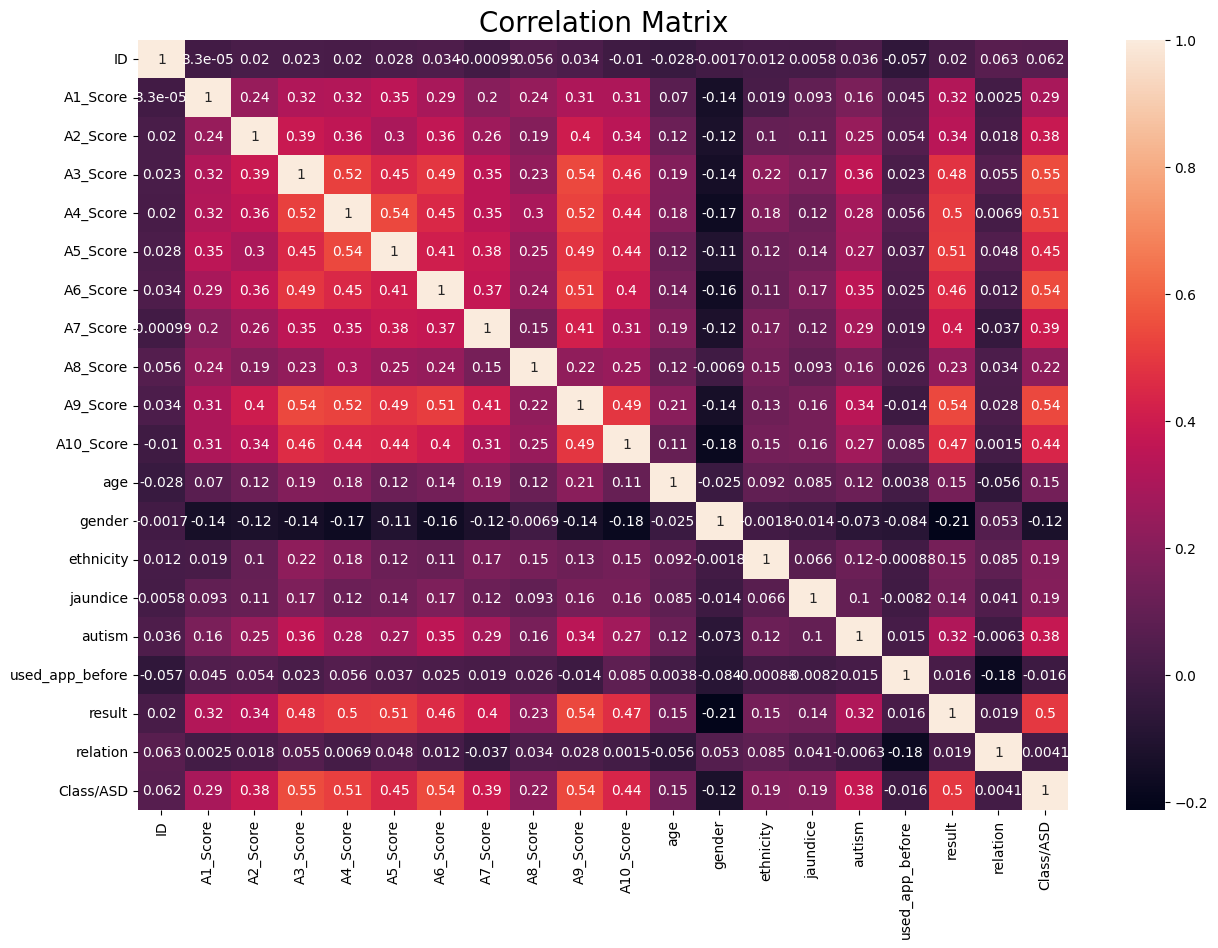

In [ ]:
plt.figure(figsize=(15, 10))
sns.heatmap(train.corr(), annot=True);
plt.title('Correlation Matrix', fontsize=20);

In [ ]:
train.corr()['Class/ASD'].sort_values(ascending=False)[1:]

A3_Score           0.549618
A6_Score           0.542588
A9_Score           0.538688
A4_Score           0.512792
result             0.496165
A5_Score           0.448473
A10_Score          0.439587
A7_Score           0.394660
A2_Score           0.380703
autism             0.377079
A1_Score           0.289991
A8_Score           0.219034
jaundice           0.190769
ethnicity          0.186302
age                0.146351
ID                 0.061677
relation           0.004093
used_app_before   -0.015853
gender            -0.124789
Name: Class/ASD, dtype: float64

## BALANCING THE CLASSES - OVERSAMPLING¶


In [ ]:
train["Class/ASD"].value_counts()

0    615
1    185
Name: Class/ASD, dtype: int64

In [ ]:
class_label = train["Class/ASD"].value_counts()
plt.figure(figsize=(10, 5))
sns.barplot(y=class_label.index,x=class_label);
plt.xlabel('Class/ASD', fontsize=20);
plt.ylabel('Count', fontsize=20)

### Oversampling

In [ ]:
from sklearn.utils import resample

# Separate Target Classes
df_1 = train[train["Class/ASD"] == 0]
df_2 = train[train["Class/ASD"] == 1]

# Upsample minority class
df_2_upsampled = resample(df_2,
                                 replace=True,     # sample with replacement
                                 n_samples=615,    # to match majority class
                                 random_state=123) # reproducible results

# Combine majority class with upsampled minority class
train_upsampled = pd.concat([df_1, df_2_upsampled])

# Display new class counts
train_upsampled["Class/ASD"].value_counts()

0    615
1    615
Name: Class/ASD, dtype: int64

### Class Distribution - After oversampling



In [ ]:
class_label = train_upsampled["Class/ASD"].value_counts()
plt.figure(figsize=(10, 5))
sns.barplot(y=class_label.index, x=class_label);
plt.xlabel('Class/ASD', fontsize=20);
plt.ylabel('Count', fontsize=20)

## BINARY CLASSIFICATION

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score,roc_curve,auc

In [ ]:
accuracy_list = []
f1_list = []
roc_auc_list = []

### Train Test Evaluation Function



In [ ]:
def result(model):

    #fit on data
    model.fit(X_train, y_train)

    #prediction
    pred = model.predict(X_test)

    #performance of model
    print("Classification Report: \n", classification_report(y_test, pred))
    print("-" * 100)
    print()

    #accuracy of model
    acc = accuracy_score(y_test, pred)
    accuracy_list.append(acc)
    print("Accuracy Score: ", acc)
    print("-" * 100)
    print()

    #f1-score of model
    f1 = f1_score(y_test, pred)
    f1_list.append(f1)
    print("F1 Score: ", f1)
    print("-" * 100)
    print()

    #roc-auc curve of model
    fpr,tpr,threshold = roc_curve(y_test,pred)
    auc_value = auc(fpr,tpr)
    rocauc_score = roc_auc_score(y_test, pred)
    roc_auc_list.append(rocauc_score)
    plt.figure(figsize=(5,5),dpi=100)
    print("ROC-AUC Score: ", f1)
    print("-" * 100)
    print()
    plt.plot(fpr,tpr,linestyle='-',label = "(auc_value = %0.3f)" % auc_value)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()
    print()

    #confusion matrix for model
    print("Confusion Matrix: ")
    plt.figure(figsize=(10, 5))
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='g');
    plt.title('Confusion Matrix', fontsize=20)

### Independent and Dependent Features



In [ ]:
x = train_upsampled.drop("ID", axis=1)
x = x.drop("Class/ASD", axis=1)
y = train_upsampled[["Class/ASD"]]

In [ ]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
#scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### Logistic Regression



/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Classification Report: 
               precision    recall  f1-score   support

           0       0.88      0.88      0.88       129
           1       0.87      0.87      0.87       117

    accuracy                           0.88       246
   macro avg       0.88      0.88      0.88       246
weighted avg       0.88      0.88      0.88       246

----------------------------------------------------------------------------------------------------

Accuracy Score:  0.8780487804878049
----------------------------------------------------------------------------------------------------

F1 Score:  0.8717948717948718
----------------------------------------------------------------------------------------------------

ROC-AUC Score:  0.8717948717948718
----------------------------------------------------------------------------------------------------



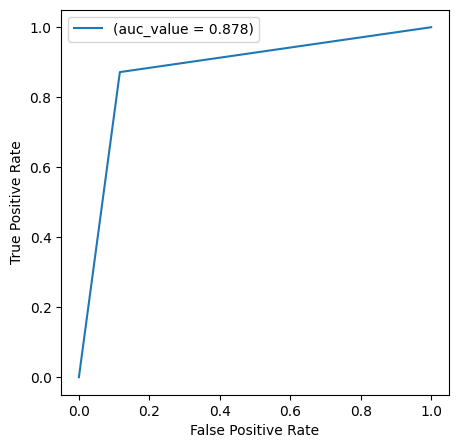


Confusion Matrix: 


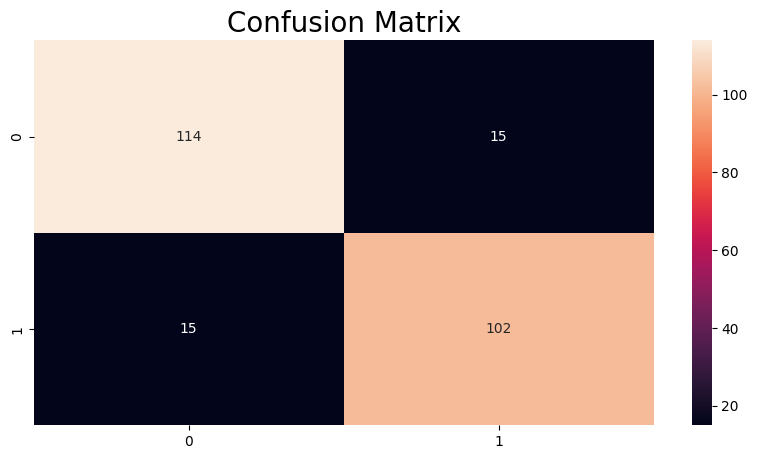

In [ ]:
lr = LogisticRegression()
result(lr)

### Random Forest Classifier



<ipython-input-67-594e471fde7e>:4: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model.fit(X_train, y_train)


Classification Report: 
               precision    recall  f1-score   support

           0       0.98      0.95      0.96       129
           1       0.94      0.98      0.96       117

    accuracy                           0.96       246
   macro avg       0.96      0.96      0.96       246
weighted avg       0.96      0.96      0.96       246

----------------------------------------------------------------------------------------------------

Accuracy Score:  0.9634146341463414
----------------------------------------------------------------------------------------------------

F1 Score:  0.9623430962343097
----------------------------------------------------------------------------------------------------

ROC-AUC Score:  0.9623430962343097
----------------------------------------------------------------------------------------------------



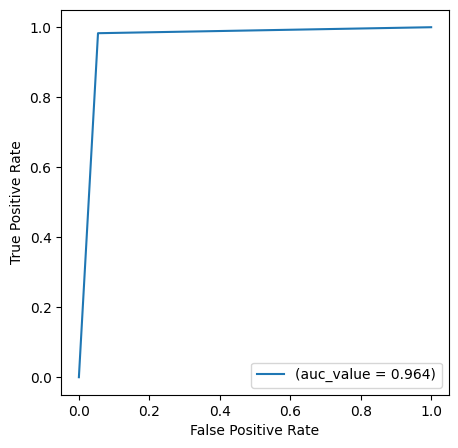


Confusion Matrix: 


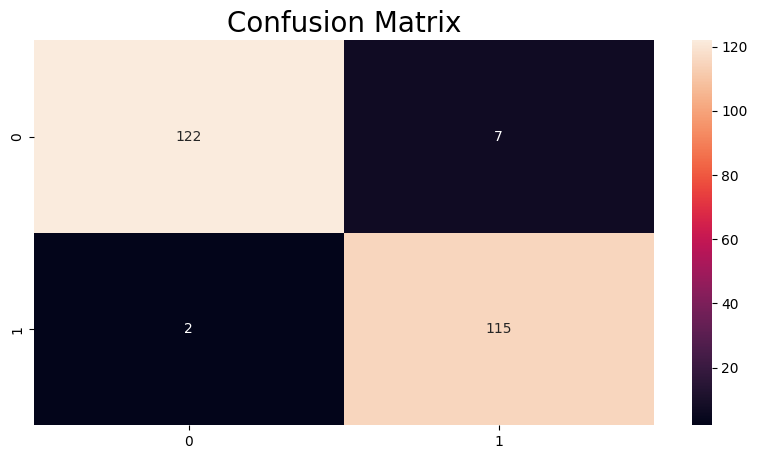

In [ ]:
rf = RandomForestClassifier()
result(rf)

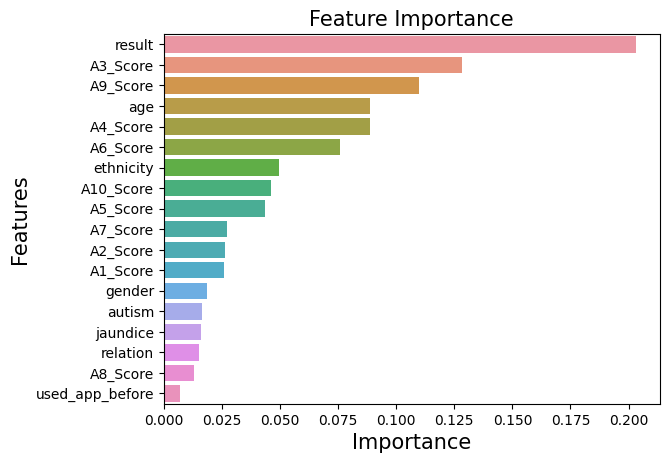

           Features  Importance
16           result    0.203254
2          A3_Score    0.128521
8          A9_Score    0.109641
10              age    0.088816
3          A4_Score    0.088719
5          A6_Score    0.075696
12        ethnicity    0.049635
9         A10_Score    0.045981
4          A5_Score    0.043512
6          A7_Score    0.027308
1          A2_Score    0.026263
0          A1_Score    0.026042
11           gender    0.018781
14           autism    0.016616
13         jaundice    0.015805
17         relation    0.015211
7          A8_Score    0.013062
15  used_app_before    0.007138


In [ ]:
important_features = pd.DataFrame({'Features': x.columns,
                                   'Importance': rf.feature_importances_})

# sort the dataframe in the descending order according to the feature importance
important_features = important_features.sort_values('Importance', ascending = False)

# create a barplot to visualize the features based on their importance
sns.barplot(x = 'Importance', y = 'Features', data = important_features)

# add plot and axes labels
# set text size using 'fontsize'
plt.title('Feature Importance', fontsize = 15)
plt.xlabel('Importance', fontsize = 15)
plt.ylabel('Features', fontsize = 15)

# display the plot
plt.show()
print(important_features)

### KNN Classifier


/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Classification Report: 
               precision    recall  f1-score   support

           0       0.92      0.88      0.90       129
           1       0.87      0.91      0.89       117

    accuracy                           0.89       246
   macro avg       0.89      0.90      0.89       246
weighted avg       0.90      0.89      0.89       246

----------------------------------------------------------------------------------------------------

Accuracy Score:  0.8943089430894309
----------------------------------------------------------------------------------------------------

F1 Score:  0.8916666666666666
----------------------------------------------------------------------------------------------------

ROC-AUC Score:  0.8916666666666666
----------------------------------------------------------------------------------------------------



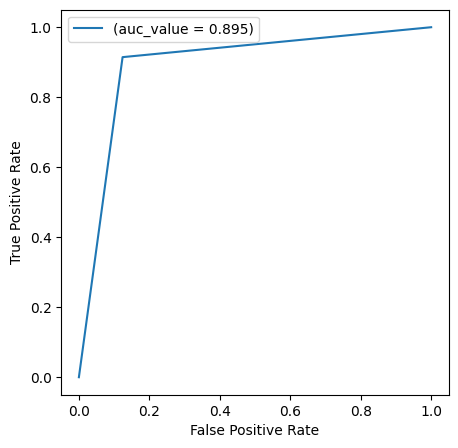


Confusion Matrix: 


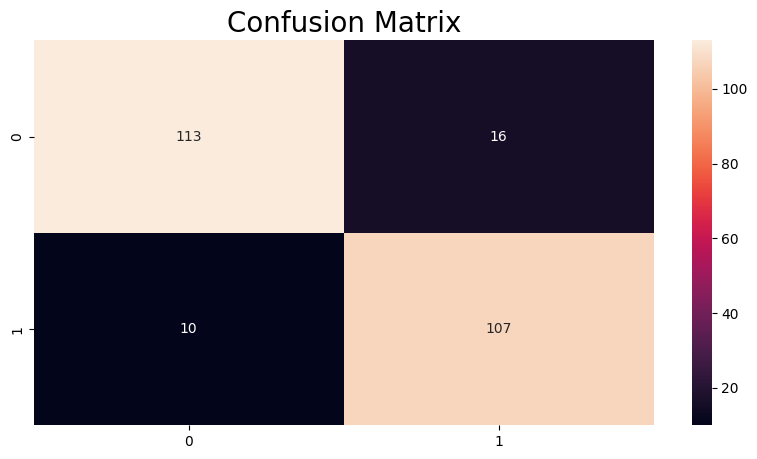

In [ ]:
knn = KNeighborsClassifier()
result(knn)


### Gradient Boosting Classifier



/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_gb.py:437: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Classification Report: 
               precision    recall  f1-score   support

           0       0.97      0.90      0.93       129
           1       0.90      0.97      0.93       117

    accuracy                           0.93       246
   macro avg       0.93      0.93      0.93       246
weighted avg       0.93      0.93      0.93       246

----------------------------------------------------------------------------------------------------

Accuracy Score:  0.9308943089430894
----------------------------------------------------------------------------------------------------

F1 Score:  0.9300411522633745
----------------------------------------------------------------------------------------------------

ROC-AUC Score:  0.9300411522633745
----------------------------------------------------------------------------------------------------



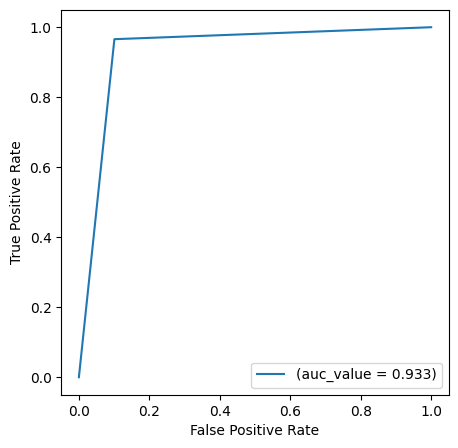


Confusion Matrix: 


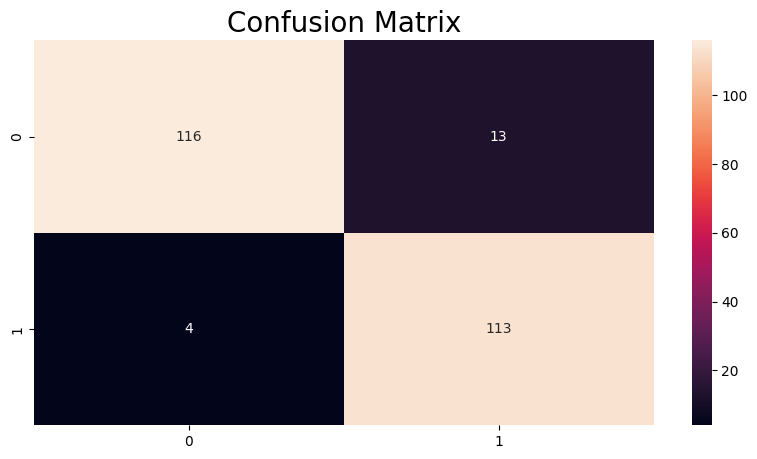

In [ ]:
gb = GradientBoostingClassifier()
result(gb)

### Naive Bayes Classifier



/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Classification Report: 
               precision    recall  f1-score   support

           0       0.89      0.90      0.90       129
           1       0.89      0.88      0.88       117

    accuracy                           0.89       246
   macro avg       0.89      0.89      0.89       246
weighted avg       0.89      0.89      0.89       246

----------------------------------------------------------------------------------------------------

Accuracy Score:  0.8902439024390244
----------------------------------------------------------------------------------------------------

F1 Score:  0.8841201716738197
----------------------------------------------------------------------------------------------------

ROC-AUC Score:  0.8841201716738197
----------------------------------------------------------------------------------------------------



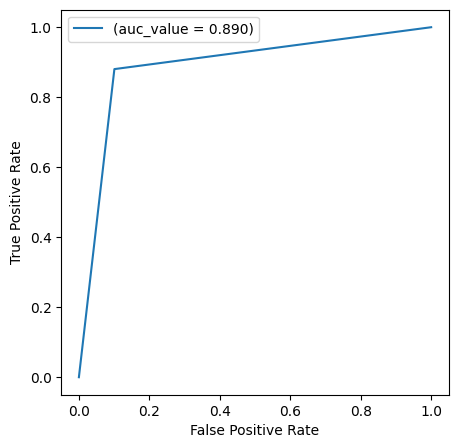


Confusion Matrix: 


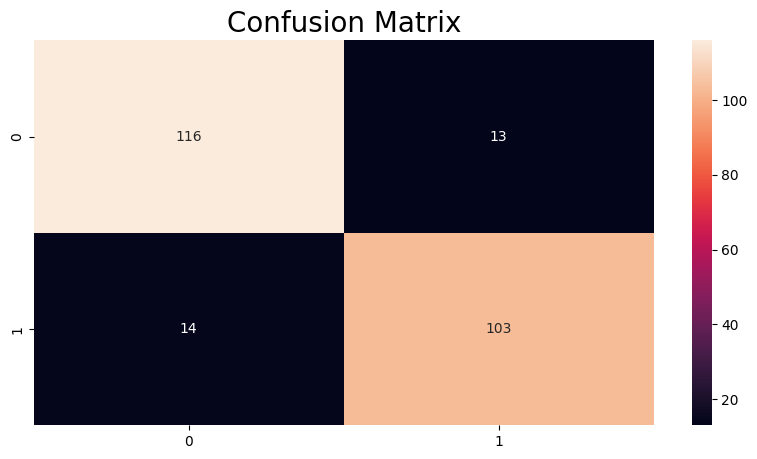

In [ ]:
nb = GaussianNB()
result(nb)

### Decision Tree Classifier



Classification Report: 
               precision    recall  f1-score   support

           0       0.97      0.88      0.93       129
           1       0.88      0.97      0.93       117

    accuracy                           0.93       246
   macro avg       0.93      0.93      0.93       246
weighted avg       0.93      0.93      0.93       246

----------------------------------------------------------------------------------------------------

Accuracy Score:  0.926829268292683
----------------------------------------------------------------------------------------------------

F1 Score:  0.9268292682926831
----------------------------------------------------------------------------------------------------

ROC-AUC Score:  0.9268292682926831
----------------------------------------------------------------------------------------------------



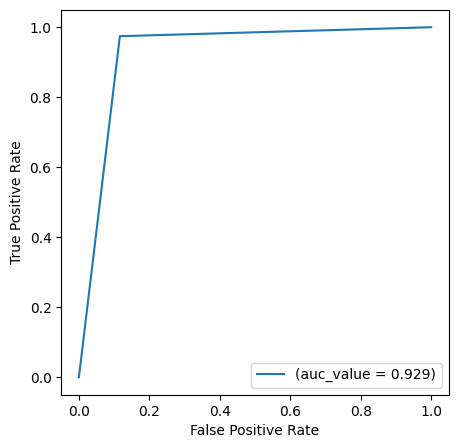


Confusion Matrix: 


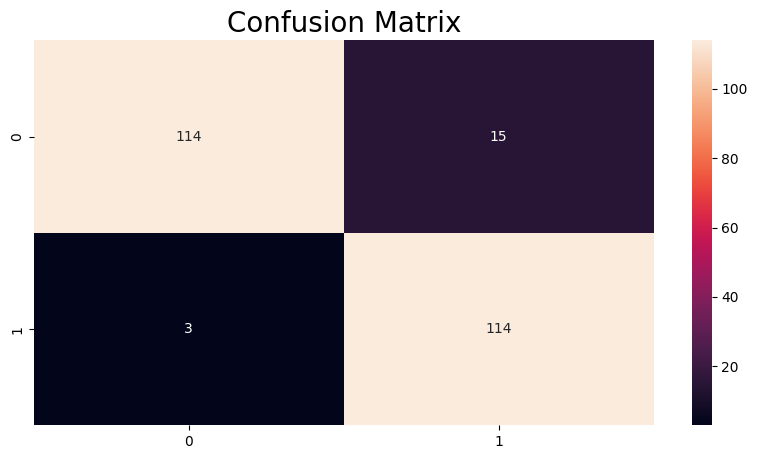

In [ ]:
dt = DecisionTreeClassifier()
result(dt)

### Stochastic Gradient Descent Classifier

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Classification Report: 
               precision    recall  f1-score   support

           0       0.86      0.78      0.82       129
           1       0.78      0.85      0.82       117

    accuracy                           0.82       246
   macro avg       0.82      0.82      0.82       246
weighted avg       0.82      0.82      0.82       246

----------------------------------------------------------------------------------------------------

Accuracy Score:  0.8170731707317073
----------------------------------------------------------------------------------------------------

F1 Score:  0.8163265306122448
----------------------------------------------------------------------------------------------------

ROC-AUC Score:  0.8163265306122448
----------------------------------------------------------------------------------------------------



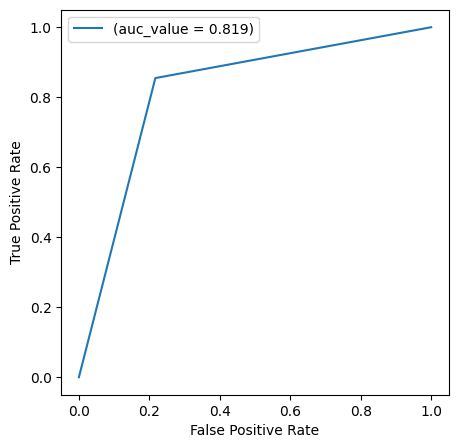


Confusion Matrix: 


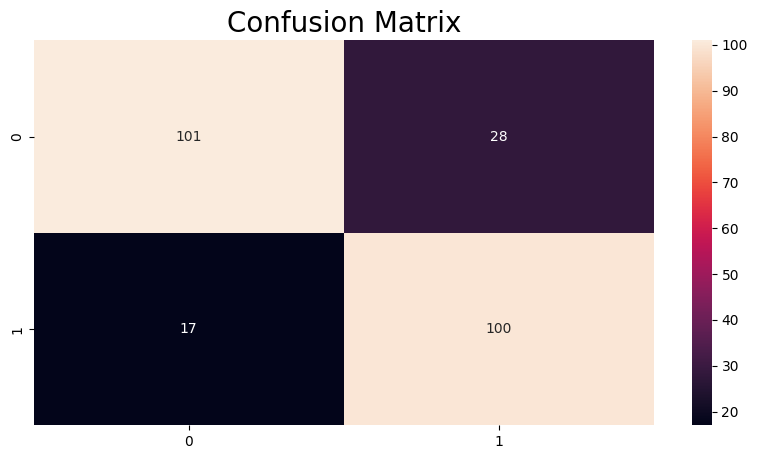

In [ ]:
sgd = SGDClassifier()
result(sgd)

### Classifier Comparison

In [ ]:
classifier_list = ["Logistic Regression", "Random Forest", "KNN", "Gradient Boosting", "XGBoost", "Naive Bayes", "Decision Tree", "Stochastic Gradient Descent"]
list_class = []
for i in range(0, len(classifier_list)):
  listclass = [classifier_list[i], accuracy_list[i], f1_list[i], roc_auc_list[i]]
  list_class.append(listclass)

list_class

[['Logistic Regression',
  0.8780487804878049,
  0.8717948717948718,
  0.877757901013715],
 ['Random Forest', 0.9634146341463414, 0.9623430962343097, 0.964321208507255],
 ['KNN', 0.8943089430894309, 0.8916666666666666, 0.8952494533889882],
 ['Gradient Boosting',
  0.9308943089430894,
  0.9300411522633745,
  0.9325183860067582],
 ['XGBoost', 0.8902439024390244, 0.8841201716738197, 0.8897833432717154],
 ['Naive Bayes', 0.8902439024390244, 0.8841201716738197, 0.8897833432717154],
 ['Decision Tree', 0.926829268292683, 0.9268292682926831, 0.9290399522957663],
 ['Stochastic Gradient Descent',
  0.8170731707317073,
  0.8163265306122448,
  0.8188232955674817]]

In [ ]:
cc_table = pd.DataFrame(list_class, columns = ["Classifier", "Accuracy", "F1 Score", "ROC-AUC Score"])
cc_table.sort_values(ascending = False, by = "Accuracy")

,Classifier,Accuracy,F1 Score,ROC-AUC Score
1,Random Forest,0.963415,0.962343,0.964321
3,Gradient Boosting,0.930894,0.930041,0.932518
6,Decision Tree,0.926829,0.926829,0.929040
2,KNN,0.894309,0.891667,0.895249
4,XGBoost,0.890244,0.884120,0.889783
5,Naive Bayes,0.890244,0.884120,0.889783
0,Logistic Regression,0.878049,0.871795,0.877758
7,Stochastic Gradient Descent,0.817073,0.816327,0.818823


<Axes: xlabel='ROC-AUC Score', ylabel='Classifier'>

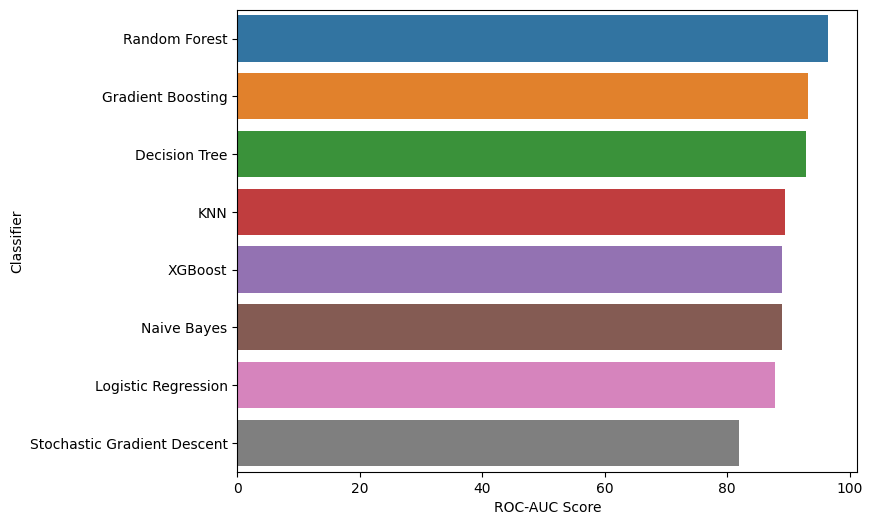

In [ ]:
plt.figure(figsize = (8,6))
sns.barplot(x = cc_table["ROC-AUC Score"]*100,
            y = cc_table["Classifier"],
            data = cc_table,
            order = cc_table.sort_values("ROC-AUC Score", ascending = False).Classifier)

## TEST DATA

### Cleaning the Test Data



In [ ]:
test.shape

(200, 21)

In [ ]:
test['age'] = test['age'].astype(int,errors='ignore')

In [ ]:
test = test.drop(["contry_of_res","age_desc"], axis=1)

In [ ]:
test = test.rename(columns={'austim':'autism'})

In [ ]:
#gender
print(test['gender'].unique())
test['gender']= label_encoder.fit_transform(test['gender'])
print(test['gender'].unique())


[1 0]
[1 0]


In [ ]:
#jaundice
print(test['jaundice'].unique())
test['jaundice']= label_encoder.fit_transform(test['jaundice'])
print(test['jaundice'].unique())

[0 1]
[0 1]


In [ ]:
#autism
print(test['autism'].unique())
test['autism']= label_encoder.fit_transform(test['autism'])
print(test['autism'].unique())

['no' 'yes']
[0 1]


In [ ]:
#used_app_before
print(test['used_app_before'].unique())
test['used_app_before']= label_encoder.fit_transform(test['used_app_before'])
print(test['used_app_before'].unique())

['no' 'yes']
[0 1]


In [ ]:
#relation
print(test['relation'].unique())
test['relation']= label_encoder.fit_transform(test['relation'])
print(test['relation'].unique())

['?' 'Parent' 'Self' 'Relative' 'Health care professional' 'Others']
[0 3 5 4 1 2]


In [ ]:
#ethnicity
print(test['ethnicity'].unique())
test['ethnicity']= label_encoder.fit_transform(test['ethnicity'])
print(test['ethnicity'].unique())

['Asian' '?' 'Middle Eastern ' 'White-European' 'Latino' 'Pasifika'
 'Black' 'Hispanic' 'South Asian' 'Others' 'Turkish' 'others']
[ 1  0  5 10  4  7  2  3  8  6  9 11]


In [ ]:
x_test = test.drop("ID", axis=1)
x_test.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,autism,used_app_before,result,relation
0,0,0,0,0,0,0,0,1,0,0,13,1,1,0,0,0,-0.914467,0
1,1,0,0,0,1,0,0,0,0,0,25,0,0,1,0,0,4.553447,3
2,1,0,0,1,0,1,0,1,0,0,28,0,1,0,0,0,-1.581115,5
3,1,1,1,0,1,0,1,0,1,1,16,0,5,1,0,0,11.779210,4
4,1,0,0,1,1,0,0,1,1,0,54,0,10,0,0,0,10.717321,5


In [ ]:
rf_classifier = RandomForestClassifier()
rf_classifier.fit(x, y)
autism_pred = rf_classifier.predict(x_test)
autism_pred = np.array(autism_pred)
autism_pred = pd.DataFrame(autism_pred)

<ipython-input-98-e64cbb1fe0c8>:2: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  rf_classifier.fit(x, y)


## Creating the output Submission file

In [ ]:
test_data = pd.read_csv("/content/test.csv")
test_data.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation
0,1,0,0,0,0,0,0,0,1,0,...,13.445319,m,Asian,no,no,United Arab Emirates,no,-0.914467,18 and more,?
1,2,1,0,0,0,1,0,0,0,0,...,25.057229,f,?,yes,no,New Zealand,no,4.553447,18 and more,Parent
2,3,1,0,0,1,0,1,0,1,0,...,28.799885,f,Asian,no,no,Austria,no,-1.581115,18 and more,Self
3,4,1,1,1,0,1,0,1,0,1,...,16.501526,f,Middle Eastern,yes,no,Bahamas,no,11.779210,18 and more,Relative
4,5,1,0,0,1,1,0,0,1,1,...,54.223869,f,White-European,no,no,Australia,no,10.717321,18 and more,Self


In [ ]:
id_value = np.array(test['ID'])
id_value = pd.DataFrame(id_value)
id_value.shape

(200, 1)

In [ ]:
final_result = pd.concat([id_value, autism_pred], join='outer', axis=1)
final_result.columns = ['ID', 'Class/ASD']
final_result

,ID,Class/ASD
0,1,0
1,2,0
2,3,0
3,4,1
4,5,0
...,...,...
195,196,0
196,197,0
197,198,1
198,199,1


In [ ]:
final_result["Class/ASD"].value_counts()

0    159
1     41
Name: Class/ASD, dtype: int64

In [ ]:
final_result.to_csv("Submission_File.csv", index=False)